**Group information**

| Family name | First name | Email address |
| ----------- | ---------- | ------------- |
|             |            |               |
|             |            |               |
|             |            |               |

# Image - Practice

In this tutorial we explore how computer vision models can be used to predict emotions from facial images. The labelled dataset available on [Kaggle](https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset) contains 35,887 images of dimensions $48 \times 48 \times 3$, representing faces expressing 7 fundamental emotions including anger, disgust, fear, happiness, neutral, sadness, and surprise. We aim to approximate the function mapping each image to a set of conditional probabilities corresponding to each emotion using a simple convolutional neural network.

In [1]:
# Packages
import numpy as np
import pandas as pd
import os
import shutil
import torch
import torchinfo

from matplotlib import pyplot as plt
from sklearn import metrics
from torch import nn, optim, utils
from torchvision import io, transforms
from tqdm import tqdm
from urllib import request

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)

# Utilities
emotions = {0:'Anger', 1:'Disgust', 2:'Fear', 3:'Happiness', 4:'Neutral', 5:'Sadness', 6:'Surprise'}

In [2]:
# Utilities
def plot_image(image:torch.Tensor, title:str='', cmap:str='gray', figsize=(5, 5)) -> None:
    image   = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image, cmap='gray')
    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

def download_data():
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fo/8ls3rbwheo8rvactkvdx0/AFVMKWwDTisjrMxDyApPAKY?rlkey=nysbl3yw84jsqk9ry1tz9xwd1&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

In [3]:
# Downloads dataset
download_data()

**1. Load data:** Use `torch.load` to load the images and labels tensors.

In [5]:
images = torch.load('emotion_images.pt')
labels = torch.load('emotion_labels.pt')

/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_37839/1536849691.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load('emotion_images.pt')
/var

**2. Descriptive statistics:** Check the dimensions of images and labels tensors using the `size` methods, calculate label frequencies, and display a few image-label examples using the provided `plot_image` function.

In [6]:
print(images.size())
print(labels.size())

torch.Size([35887, 1, 48, 48])
torch.Size([35887])


In [7]:
unique, counts = torch.unique(labels, return_counts=True)
print(unique)
print(counts)

tensor([0, 1, 2, 3, 4, 5, 6])
tensor([4953,  547, 5121, 8989, 6198, 6077, 4002])


In [8]:
label_frequency = pd.DataFrame({'Emotion': [emotions[i.item()] for i in unique], 'Frequency': counts.numpy(), 'Percentage': counts.numpy() / len(labels) * 100})
print(label_frequency)

     Emotion  Frequency  Percentage
0      Anger       4953   13.801655
1    Disgust        547    1.524229
2       Fear       5121   14.269791
3  Happiness       8989   25.048068
4    Neutral       6198   17.270878
5    Sadness       6077   16.933709
6   Surprise       4002   11.151671


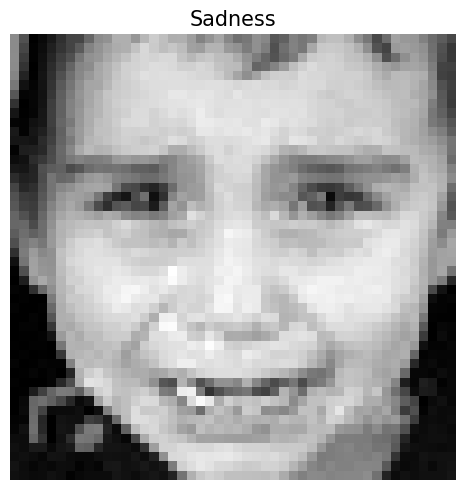

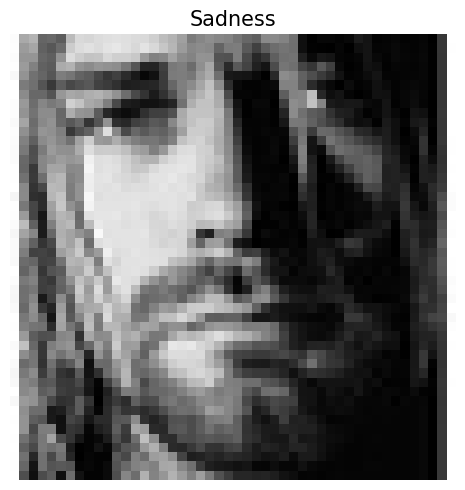

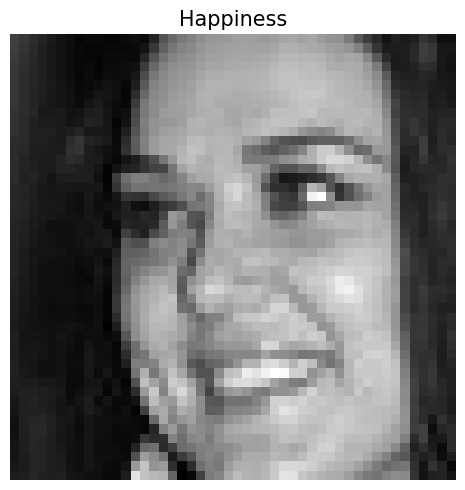

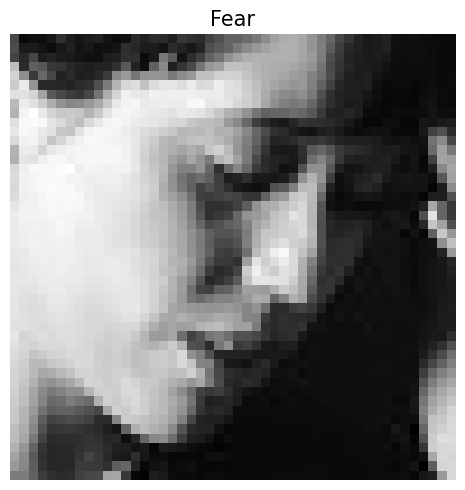

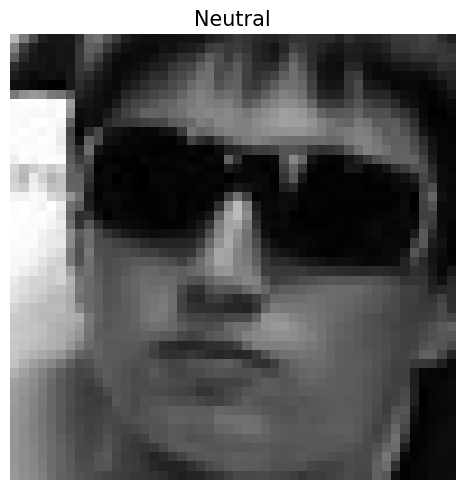

In [9]:
n = 5
random_indices = torch.randperm(len(images))[:n]

for idx in random_indices:
    plot_image(images[idx], title=emotions[labels[idx].item()])    

**3. Data formatting:** Convert the images tensor to `torch.float32` and normalise them to the `[0, 1]` range. Convert the labels tensor to `torch.int64` (or `torch.long`) as required by the cross-entropy loss function.

In [10]:
images = images.float() / 255.0

labels = labels.long()

print(f"Images dtype: {images.dtype}, range: [{images.min()}, {images.max()}]")
print(f"Labels dtype: {labels.dtype}")

Images dtype: torch.float32, range: [0.0, 1.0]
Labels dtype: torch.int64


**4. Train-test split:** Randomly partition images and labels into a training sample (75%) and a test sample (25%). Create PyTorch datasets (`utils.data.TensorDataset`) and data loaders (`utils.data.DataLoader`).

In [ ]:
# Train-test split (75% train, 25% test) and dataloaders
torch.manual_seed(0)

total_samples = len(images)
split_idx = int(0.75 * total_samples)
perm = torch.randperm(total_samples, device=images.device)

train_idx, test_idx = perm[:split_idx], perm[split_idx:]

train_images, train_labels = images[train_idx], labels[train_idx]
test_images, test_labels = images[test_idx], labels[test_idx]

batch_size = 64

train_dataset = utils.data.TensorDataset(train_images, train_labels)
test_dataset  = utils.data.TensorDataset(test_images,  test_labels)

train_loader = utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Total: {total_samples}, Train: {len(train_dataset)}, Test: {len(test_dataset)}")

In [11]:
torch.manual_seed(0)

total_samples = len(images)
split_idx = int(0.75 * total_samples)
perm = torch.randperm(total_samples, device=images.device)

train_idx, test_idx = perm[:split_idx], perm[split_idx:]

train_images, train_labels = images[train_idx], labels[train_idx]
test_images, test_labels = images[test_idx], labels[test_idx]

batch_size = 64

train_dataset = utils.data.TensorDataset(train_images, train_labels)
test_dataset  = utils.data.TensorDataset(test_images,  test_labels) 

train_loader = utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Total: {total_samples}, Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Total: 35887, Train: 26915, Test: 8972


**5. Model structure:** Define a PyTorch model class for a simple convolutional network with the following structure:

- Three blocks of layers with $d = 8, 16, 32$ convolutional filters, respectively:
    - Convolution (`nn.Conv2d`) with $d$ filters of size $3 \times 3$
    - ReLU activation (`nn.ReLU`)
    - $2 \times 2$ max pooling (`nn.MaxPool2d`)
- A global average pooling layer (`nn.AdaptiveAvgPool2d`)
- A linear output layer (`nn.Linear`)

Instantiate the model and print the model structure.

Note: For numerical stability, PyTorch loss functions expect raw logit scores rather than probability distributions. The softmax transformation is applied internally within the loss function.

In [12]:
in_channels = images.size(1)
height, width = images.size(2), images.size(3)
num_classes = len(unique)

class SimpleCNN(nn.Module):
    def __init__(self, in_ch, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = SimpleCNN(in_channels, num_classes).to(device)

print(model)
try:
    torchinfo.summary(model, input_size=(batch_size, in_channels, height, width), device=str(device))
except Exception:
    pass

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=32, out_features=7, bias=True)
)


**6. Loss function and optimiser:** Define the appropriate loss function (`nn.CrossEntropyLoss`) and an optimisation algorithm (e.g. `optim.AdamW`).

In [ ]:
# Loss function and optimiser
class_weights = (1.0 / counts.float()).to(device)          # inverse-frequency weights
class_weights = class_weights / class_weights.sum() * num_classes

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

**7. Model training:** Write a PyTorch training loop to estimate the model parameters using the training sample, with a maximum of 100 epochs. 

Note: When using `cuda` or `mps` devices, make sure to move both the model and the input tensors to the appropriate device, and to move back the output tensor to `cpu`.

In [ ]:
# 7) Model training (simple loop)
max_epochs = 100

for epoch in range(max_epochs):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)

    epoch_loss = running_loss / len(train_dataset)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{max_epochs} - Train loss: {epoch_loss:.4f}")



**8. Model evaluation:** Write a PyTorch evaluation loop to assess the model's generalisation performance on the test sample.

In [ ]:
# 8) Model evaluation (simple loop)
model.eval()
test_loss = 0.0
correct = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        test_loss += loss.item() * x_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()

avg_test_loss = test_loss / len(test_dataset)
test_acc = correct / len(test_dataset)

print(f"Test loss: {avg_test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2%}")



**9. Confusion matrix:** Display a sample of test images alongside their predicted labels. Compute the confusion matrix and interpret the results.

In [ ]:
# 9) Confusion matrix: sample predictions + confusion matrix + interpretation
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1).cpu()

        all_preds.append(preds)
        all_true.append(y_batch.cpu())

y_true = torch.cat(all_true)
y_pred = torch.cat(all_preds)

# Display sample test images with true/predicted labels
n_show = min(8, len(test_dataset))
cols = 4
rows = int(np.ceil(n_show / cols))

sample_idx = torch.randperm(len(test_dataset))[:n_show]
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)

for i, idx in enumerate(sample_idx):
    image, true_label = test_dataset[idx]
    pred_label = y_pred[idx]

    img = image.permute(1, 2, 0).squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"T: {emotions[true_label.item()]}\nP: {emotions[pred_label.item()]}", fontsize=10)
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Confusion matrix
label_order = list(emotions.keys())
cm = metrics.confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=label_order)

disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[emotions[i] for i in label_order]
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# Interpretation helpers
accuracy = (y_true == y_pred).float().mean().item()
print(f"Overall test accuracy: {accuracy:.2%}")

row_totals = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_totals, where=row_totals != 0)  # per-class recall matrix

for i, cls in enumerate(label_order):
    print(f"Recall - {emotions[cls]}: {cm_norm[i, i]:.2%}")

# Show strongest confusions (off-diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
if cm_off.sum() > 0:
    top_pairs = np.dstack(np.unravel_index(np.argsort(cm_off.ravel())[::-1], cm_off.shape))[0]
    print("\nTop confusions:")
    shown = 0
    for r, c in top_pairs:
        if cm_off[r, c] == 0 or shown == 5:
            break
        print(f"True {emotions[label_order[r]]} -> Pred {emotions[label_order[c]]}: {cm_off[r, c]}")
        shown += 1



**10. Prediction:** Take a selfie and run it through the model to predict the emotion.

**Bonus (advanced)**:  Use a PyTorch hook to extract the output of the last hidden layer. Apply a distance-preserving dimensionality reduction technique (e.g. UMAP or t-SNE) to visualise the resulting embedding space.